In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import cv2
import matplotlib.pylab as plt


In [3]:
path = "indiana_projections.csv"
df = pd.read_csv(path)
indpro = df.copy()
indpro.head()

,uid,filename,projection
0,1,1_IM-0001-4001.dcm.png,Frontal
1,1,1_IM-0001-3001.dcm.png,Lateral
2,2,2_IM-0652-1001.dcm.png,Frontal
3,2,2_IM-0652-2001.dcm.png,Lateral
4,3,3_IM-1384-1001.dcm.png,Frontal


In [4]:
path = "indiana_reports.csv"
df = pd.read_csv(path)
indrep = df.copy()
indrep.head()

,uid,MeSH,Problems,image,indication,comparison,findings,impression
0,1,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
1,2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
2,3,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,NaN,"No displaced rib fractures, pneumothorax, or p..."
3,4,"Pulmonary Disease, Chronic Obstructive;Bullous...","Pulmonary Disease, Chronic Obstructive;Bullous...","PA and lateral views of the chest XXXX, XXXX a...",XXXX-year-old XXXX with XXXX.,None available,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...
4,5,Osteophyte/thoracic vertebrae/multiple/small;T...,Osteophyte;Thickening;Lung,Xray Chest PA and Lateral,Chest and nasal congestion.,NaN,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
indpro = indpro[indpro['projection'] == 'Frontal']

In [7]:
indpro.head()

,uid,filename,projection
0,1,1_IM-0001-4001.dcm.png,Frontal
2,2,2_IM-0652-1001.dcm.png,Frontal
4,3,3_IM-1384-1001.dcm.png,Frontal
6,4,4_IM-2050-1001.dcm.png,Frontal
8,5,5_IM-2117-1003002.dcm.png,Frontal


In [8]:
indpro['uid'].value_counts()

,count
uid,
1303,4
3965,3
3307,3
3932,3
2280,3
...,...
1367,1
1368,1
1369,1


In [9]:
indpro = indpro.drop_duplicates(subset = 'uid',keep = 'first')

In [10]:
indpro['uid'].value_counts()

,count
uid,
3999,1
1,1
2,1
3,1
4,1
...,...
14,1
13,1
12,1


In [11]:
indrep.drop(columns = ['Problems', 'image', 'indication', 'comparison'], inplace = True)

In [12]:
indrep.head()

,uid,MeSH,findings,impression
0,1,normal,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
1,2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
2,3,normal,NaN,"No displaced rib fractures, pneumothorax, or p..."
3,4,"Pulmonary Disease, Chronic Obstructive;Bullous...",There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...
4,5,Osteophyte/thoracic vertebrae/multiple/small;T...,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.


In [13]:
indrep.shape, indpro.shape

((3851, 4), (3689, 3))

In [14]:
indrep_uid_list = indrep['uid'].to_list()
indpro_uid_list = indpro['uid'].to_list()

In [15]:
remove_rows_indices = list(set(indrep_uid_list) - set(indpro_uid_list))
remove_rows_indices.sort()

In [16]:
actual_remove_rows_indices = list()
for i in remove_rows_indices:
    actual_remove_rows_indices.append(int(indrep[indrep['uid'] == i].index[0]))

In [17]:
indrep.drop(actual_remove_rows_indices,inplace = True)

In [18]:
indrep.shape, indpro.shape

((3689, 4), (3689, 3))

In [19]:
indrep.to_csv('new_indiana_reports', index = False)
indpro.to_csv('new_indiana_projections', index = False)

In [20]:
path = 'new_indiana_reports'
df = pd.read_csv(path)
indrep = df.copy()
indrep.head()

,uid,MeSH,findings,impression
0,1,normal,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
1,2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
2,3,normal,NaN,"No displaced rib fractures, pneumothorax, or p..."
3,4,"Pulmonary Disease, Chronic Obstructive;Bullous...",There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...
4,5,Osteophyte/thoracic vertebrae/multiple/small;T...,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.


In [21]:
path = 'new_indiana_projections'
df = pd.read_csv(path)
indpro = df.copy()
indpro.head()

,uid,filename,projection
0,1,1_IM-0001-4001.dcm.png,Frontal
1,2,2_IM-0652-1001.dcm.png,Frontal
2,3,3_IM-1384-1001.dcm.png,Frontal
3,4,4_IM-2050-1001.dcm.png,Frontal
4,5,5_IM-2117-1003002.dcm.png,Frontal


In [22]:
indiana_data = indrep.merge(indpro[['uid','filename']], on = 'uid', how = 'left')

In [23]:
indiana_data.head()

,uid,MeSH,findings,impression,filename
0,1,normal,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.,1_IM-0001-4001.dcm.png
1,2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.,2_IM-0652-1001.dcm.png
2,3,normal,NaN,"No displaced rib fractures, pneumothorax, or p...",3_IM-1384-1001.dcm.png
3,4,"Pulmonary Disease, Chronic Obstructive;Bullous...",There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...,4_IM-2050-1001.dcm.png
4,5,Osteophyte/thoracic vertebrae/multiple/small;T...,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.,5_IM-2117-1003002.dcm.png


In [24]:
indiana_data.isnull().sum()

,0
uid,0
MeSH,0
findings,490
impression,29
filename,0


In [25]:
indiana_data = indiana_data.dropna()

In [26]:
indiana_data.isnull().sum()

,0
uid,0
MeSH,0
findings,0
impression,0
filename,0


In [27]:
indiana_data['label'] = 'null'

In [28]:
nor = indiana_data[indiana_data['MeSH'].str.contains("normal",case=False,na=False)]['uid'].to_list()

In [29]:
indiana_data.loc[indiana_data['uid'].isin(nor),'label'] = 'normal'

In [30]:
other = set(indiana_data['uid'].to_list()) - set(nor)
indiana_data.loc[indiana_data['uid'].isin(other),'label'] = 'abnormal'

In [31]:
indiana_data.head()

,uid,MeSH,findings,impression,filename,label
0,1,normal,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.,1_IM-0001-4001.dcm.png,normal
1,2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.,2_IM-0652-1001.dcm.png,abnormal
3,4,"Pulmonary Disease, Chronic Obstructive;Bullous...",There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...,4_IM-2050-1001.dcm.png,abnormal
4,5,Osteophyte/thoracic vertebrae/multiple/small;T...,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.,5_IM-2117-1003002.dcm.png,abnormal
5,6,normal,Heart size and mediastinal contour are within ...,No acute cardiopulmonary findings.,6_IM-2192-1001.dcm.png,normal


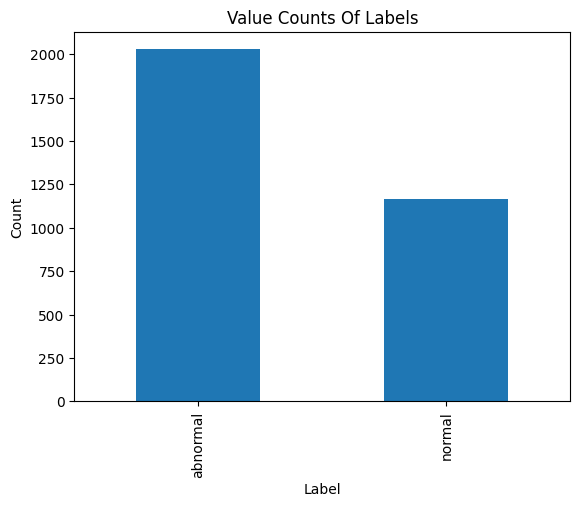

In [32]:
indiana_data['label'].value_counts().plot(kind='bar')
plt.xlabel('Label')
plt.ylabel('Count')
plt.title("Value Counts Of Labels")
plt.show()

In [33]:
indiana_data['label'].value_counts(normalize = True)

,proportion
label,
abnormal,0.634826
normal,0.365174


In [34]:
import os
from PIL import Image
from collections import Counter

required_folder = "/content/drive/MyDrive/required_images"

size_counts = Counter()
for filename in os.listdir(required_folder):
    img_path = os.path.join(required_folder,filename)
    with Image.open(img_path) as img:
         size_counts[img.size] += 1
print(size_counts)



Counter({(2496, 2048): 1070, (2048, 2048): 640, (2048, 2496): 362, (2051, 2048): 131, (2494, 2048): 113, (2474, 2048): 84, (2500, 2048): 42, (2048, 2494): 22, (2486, 2048): 21, (2048, 2050): 20, (2048, 2486): 14, (2048, 2474): 13, (2048, 2499): 12, (2048, 2052): 11, (2048, 2056): 9, (2048, 2051): 9, (2052, 2048): 9, (2048, 2049): 9, (2050, 2048): 8, (2057, 2048): 8, (2048, 2072): 8, (2055, 2048): 8, (2048, 2053): 7, (2048, 2054): 7, (2054, 2048): 7, (2048, 2059): 7, (2048, 2079): 7, (2049, 2048): 7, (2135, 2048): 6, (2063, 2048): 6, (2495, 2048): 6, (2048, 2062): 5, (2048, 2061): 5, (2048, 2063): 5, (2048, 2073): 5, (2048, 2064): 5, (2048, 2057): 5, (2048, 2070): 5, (2048, 2060): 4, (2139, 2048): 4, (2060, 2048): 4, (2056, 2048): 4, (2053, 2048): 4, (2076, 2048): 4, (2022, 2022): 4, (2224, 2048): 3, (2048, 2058): 3, (2075, 2048): 3, (2102, 2048): 3, (2189, 2048): 3, (2048, 2068): 3, (2048, 2065): 3, (2073, 2048): 3, (2499, 2048): 3, (2048, 2198): 3, (2048, 2095): 3, (2048, 2195): 3, (2

In [35]:
for filename in os.listdir(required_folder):
    img_path = os.path.join(required_folder,filename)
    size_bytes = os.path.getsize(img_path)
    size_kb = size_bytes / 1024
    print(f"{filename}: {size_kb:.2f} KB")

2742_IM-1197-1001.dcm.png: 1692.54 KB
2762_IM-1208-1001.dcm.png: 2046.62 KB
2754_IM-1204-2002.dcm.png: 2302.88 KB
2758_IM-1206-1001.dcm.png: 1640.64 KB
2748_IM-1198-1001.dcm.png: 1763.85 KB
2759_IM-1207-1001.dcm.png: 1451.63 KB
2775_IM-1216-3001.dcm.png: 2059.35 KB
2751_IM-1201-1001.dcm.png: 1987.67 KB
2769_IM-1212-1001.dcm.png: 2002.73 KB
2753_IM-1203-1001.dcm.png: 2098.94 KB
2777_IM-1217-1001.dcm.png: 2076.34 KB
2770_IM-1213-1001.dcm.png: 1634.52 KB
2746_IM-1198-1001.dcm.png: 1741.81 KB
2780_IM-1218-1002.dcm.png: 1940.81 KB
2749_IM-1199-1001.dcm.png: 1937.32 KB
2747_IM-1198-1001.dcm.png: 2039.94 KB
2740_IM-1195-1001.dcm.png: 1578.65 KB
2781_IM-1219-1001.dcm.png: 2047.63 KB
2771_IM-1213-1001.dcm.png: 2011.60 KB
2782_IM-1220-1001.dcm.png: 2016.85 KB
2784_IM-1220-1001.dcm.png: 2176.18 KB
2828_IM-1247-1001.dcm.png: 1716.89 KB
2822_IM-1244-2002.dcm.png: 2420.54 KB
2842_IM-1254-1001.dcm.png: 2016.84 KB
2848_IM-1256-1001.dcm.png: 2017.65 KB
2847_IM-1256-1001.dcm.png: 1756.82 KB
2821_IM-1244

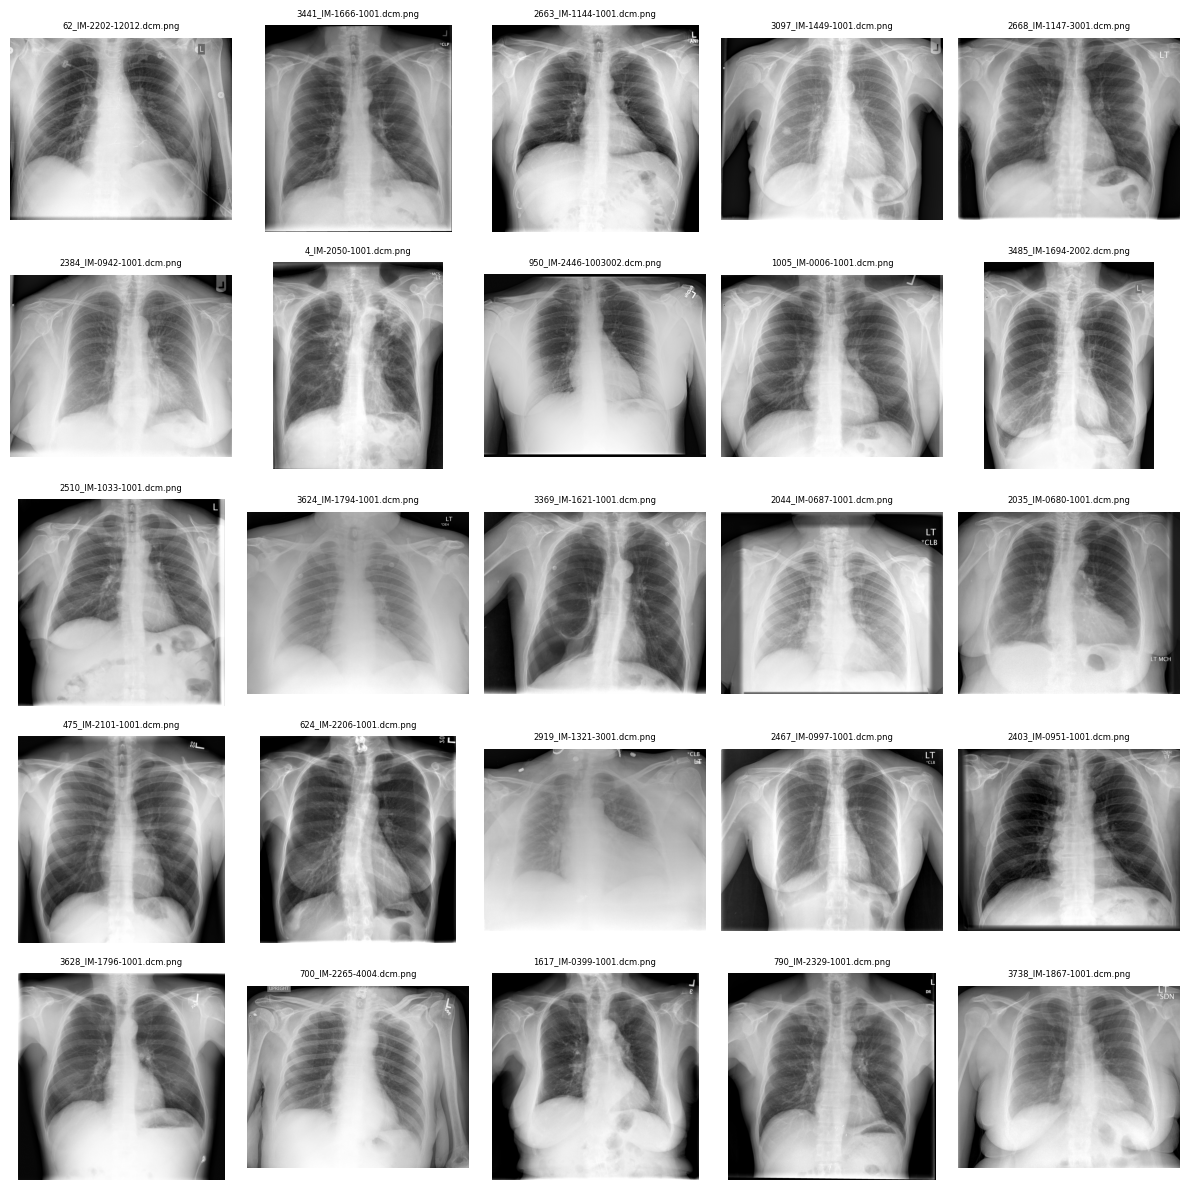

In [36]:
import random

image_folder = "/content/drive/MyDrive/required_images"
files = [f for f in os.listdir(image_folder)]
sample_files = random.sample(files,25)

fig, axes = plt.subplots(5,5,figsize = (12,12))
for ax,file in zip(axes.ravel(),sample_files):
    img = cv2.imread(os.path.join(image_folder,file),cv2.IMREAD_GRAYSCALE)
    ax.imshow(img,cmap="gray")
    ax.set_title(file,fontsize = 6)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [37]:
from torchvision import transforms

In [38]:
from sklearn.model_selection import train_test_split

train_df,temp_df = train_test_split(
    indiana_data,
    test_size = 0.2,
    random_state = 42,
    stratify = indiana_data['label']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size = 0.5,
    random_state = 42,
    stratify = temp_df['label']
)

In [39]:
from PIL import Image

def train_transform_pipeline(filepath):
    transform = transforms.Compose([
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomResizedCrop(size=224, scale=(0.9, 1.0)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    img = cv2.imread(filepath, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = Image.fromarray(img)
    img = transform(img)
    return img

In [40]:
def transform_pipeline(filepath):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    img = cv2.imread(filepath, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = transform(img)
    return img

In [41]:
indiana_data.to_csv("labeled_data.csv",index = False)